<hr style="border:1px solid #808080">                                                                                                                   </hr>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>Ayudantía 2 - Repaso Python</b>                                                                           </h1>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>IBM2020 Introducción a la Biomecánica</b>                                                                           </h1>
<p style=padding:0;margin:0>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;"> Profesor - <span style="color:#dbdbdb;text-align:center;"><b>Daniel Hurtado</b></span></h3>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;">Ayudantes - <span style="color:#dbdbdb;text-align:center;"><b>Vicente Zúñiga, Clio Kipreos</b></span></h3> 
</p>
<h4 style="color:#dbdbdb;text-align:center;margin:0;padding:0;">Instituto de Ingeniería Biológica y Médica<br>Escuela de Ingeniería<br>  Pontificia Universidad Católica de Chile <br></h4>
<hr style="border:1px solid #808080">                                                                                                                   </hr>

## Introducción
La biomecánica estudia el comportamiento mecánico de los tejidos blandos, usualmente sometidos a grandes deformaciones, y que presentan relaciones no lineales entre tensión y deformación. Para describir cuantitativamente este comportamiento, es necesario saber definir un dominio $\Omega$ que represente el cuerpo a estudiar, cómo aplicar deformaciones, graficar sus tensiones y extraer resultados que se puedan entender fácilmente. 


## Instalación de Python
Existen diversos lenguajes de programación (e.g. C++, MATLAB/Octave, Julia, etc.) y software (Abaqus, FEBio, COMSOL Multiphysics) para simulación computacional y experimentación numérica de modelos biomecánicos definidos en geometrías arbitrarias. En este curso, usaremos **Python** como herramienta de computación científica, junto con algunas librerías.

Lo mejor es instalar Python directamente desde su [sitio web](https://www.python.org/downloads/). Alternativamente, es posible usar Anaconda u otra distribución de Python, pero usualmente generan muchos problemas para poder instalar librerías más avanzadas, como FEniCSx. También es posible correr código en línea usando [Google Colab](https://colab.research.google.com), lo que es ideal para cuando uno no dispone de una CPU o GPU con suficiente poder de procesamiento.
## Instalación de packages/librerías
Existen muchos paquetes y librerías para ampliar las funcionalidades que ofrece Python. Usualmente éstas se instalan vía `pip install library-name` en la consola de comandos Windows/Linux. 
### Jupyter Notebooks
Jupyter es una plataforma basada en web para programar de forma interactiva en celdas, con anotaciones en el lenguaje [Markdown](https://www.markdownguide.org/basic-syntax/). Para instalarlo, deben escribir en la consola `pip install jupyterlab` para Jupyter Lab, donde podrán crear Jupyter Notebooks y correrlos en un navegador web. Para iniciar Jupyter Lab, deben escribir en la consola `jupyter lab`.

Alternativamente, si se encuentran en un IDE como VSCode, pueden instalarlo mediante la extensión `jupyter`.

Otra manera de utilizarlo es mediante Google Colab, que funciona por defecto con jupyter notebooks sin la necesidad de instalar nada.

### Librerías para computación científica
- `NumPy`: mediante `pip install numpy`. [Documentación y tutoriales](https://numpy.org/doc/)
- `Matplotlib`: mediante `pip install matplotlib`. [Documentación y tutoriales](https://matplotlib.org/stable/users/index.html)
- `SciPy`: mediante `pip install scipy`. [Documentación](https://docs.scipy.org/doc/scipy/)

## Importar librerías y archivos .py externos
    

In [1]:
import sys
import os
import time

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp

from my_func import damped_oscillation

# Este codigo recarga automaticamente los cambios en los modulos que importamos.
%load_ext autoreload
%autoreload 2

## Operaciones básicas en Python

In [2]:
a = 2       # El valor 2 (int) está asignado a "a"
b = 3.      # El valor 3 (float) está asignado a "b"
b += a      # Se le reasigna a b su valor referenciado, más el referenciado en a
print(b)

5.0


In [3]:
c = 2E3     # Se pueden declarar números en notación científica
d = b*c     # Multiplicación con *, división con /
e = c**b    # Exponenciación con **, no con ^
e

3.2e+16

## Operaciones básicas en NumPy

In [4]:
R = 4
area = np.pi*R**2
area

50.26548245743669

In [5]:
Rs = np.array([4,5,6])      # Creación de arrays a partir de listas
areas = np.pi*Rs**2
areas

array([ 50.26548246,  78.53981634, 113.09733553])

In [6]:
L = np.array(               # Creación de arrays n-dimensionales a partir de listas anidadas
    [
        [1,0,0],
        [1,1,0],
        [1,1,1]
    ]
)
L

array([[1, 0, 0],
       [1, 1, 0],
       [1, 1, 1]])

In [7]:
print(type(L))
print(L.shape) # muy util para debuggear codigo con arrays
print(L.size)

<class 'numpy.ndarray'>
(3, 3)
9


In [8]:
L[0]

array([1, 0, 0])

In [9]:
L[0,1]

np.int64(0)

In [10]:
L[:,:]

array([[1, 0, 0],
       [1, 1, 0],
       [1, 1, 1]])

In [11]:
L[0,-1]

np.int64(0)

In [12]:
rango = np.arange(0, 50)            # Todos los números entre 0 y 49.
intervalo = np.linspace(0, 50, 11)   # El intervalo [0,50], dividido en 12 partes iguales.

In [13]:
print(intervalo)

intervalo_transformado = 2 * intervalo + 5
print(intervalo_transformado)

[ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50.]
[  5.  15.  25.  35.  45.  55.  65.  75.  85.  95. 105.]


## Álgebra lineal con _arrays_ de NumPy
Existen las clases `numpy.array` y `numpy.matrix`, que tienen diferencias sutiles en la sintaxis de algunas operaciones. Nos quedaremos con la clase `numpy.array`.

In [14]:
A = np.array(           # Matriz de 3x3
    [
        [1,2,3],
        [1,0,1],
        [2,1,-1]
    ]
)
B = np.array(           # Matriz de 3x3
    [
        [2,-1,0],
        [-1,2,-1],
        [0,-1,2]
    ]
)

b = np.array([4,2,0,1])   # Vector fila, de 1x4

print(A.shape)
print(B.shape)
print(b.shape)

(3, 3)
(3, 3)
(4,)


In [15]:
detA = np.linalg.det(A)     # Determinante de una matriz
Ainv = np.linalg.inv(A)     # Inversa de una matriz
Ident = np.eye(3)           # Matriz identidad de 3x3

np.array_equal(Ident, A@Ainv)
print(A@Ainv)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Resolución de un sistema lineal $Ax=b$

In [16]:
n = 5000 # tamaño de la matriz

A = np.diag(-1*np.ones(n)) + np.diag(2*np.ones(n-1), k=1) + np.diag(2*np.ones(n-1), k=-1)
print(A)
print(A.shape)

b = np.random.rand(n)
print(b)

[[-1.  2.  0. ...  0.  0.  0.]
 [ 2. -1.  2. ...  0.  0.  0.]
 [ 0.  2. -1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  2.  0.]
 [ 0.  0.  0. ...  2. -1.  2.]
 [ 0.  0.  0. ...  0.  2. -1.]]
(5000, 5000)
[0.22383592 0.38324284 0.1790399  ... 0.71773433 0.6477997  0.73106469]


In [17]:
# Forma 1, invirtiendo

t1 = time.time()
Ainv = np.linalg.inv(A)
x1 = Ainv @ b.T
print(f"Tiempo transcurrido: {time.time() - t1}")


# Forma 2, usando np.linalg.solve

t2 = time.time()
x2 = np.linalg.solve(A, b)
print(f"Tiempo transcurrido: {time.time() - t2}")


Tiempo transcurrido: 3.9493722915649414
Tiempo transcurrido: 2.9043526649475098


In [18]:
print(np.array_equal(x1, x2)) # Deberia ser True, pero no lo es. Por que?

# Se muestran 20 decimales del primer elemento de cada solucion
np.set_printoptions(precision=16)

print(x1[0])
print(x2[0])

np.set_printoptions(precision=8)
# En la practica se puede trabajar con ambos resultados.

False
-12.052877645142445
-12.05287764514247


### Diagonalización

In [19]:
M = np.array(           
    [
        [1,2,3],
        [1,0,1],
        [2,1,-1]
    ]
)

try: 
    eigvals, eigvecs = np.linalg.eig(M)
    M_decomp = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs) # M = P D P^-1
    print(M_decomp) 
    print(np.allclose(M, M_decomp, atol=1E-10))
    print("La matriz M es diagonalizable.")
except:
    print("La matriz M no es diagonalizable.")

[[ 1.00000000e+00  2.00000000e+00  3.00000000e+00]
 [ 1.00000000e+00 -3.49319088e-16  1.00000000e+00]
 [ 2.00000000e+00  1.00000000e+00 -1.00000000e+00]]
True
La matriz M es diagonalizable.


### Descomposición de Cholesky $A=LL^T$

In [20]:
try:
    L_A = np.linalg.cholesky(A)
    print(L_A @ L_A.T)          # Descomposición de Cholesky
except:
    print("La matriz no A no es simétrica y definida positiva.")

try:
    L_B = np.linalg.cholesky(B)
    print(L_B @ L_B.T)          # Descomposición de Cholesky
except:
    print("La matriz no B no es simétrica y definida positiva.")


La matriz no A no es simétrica y definida positiva.
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]


## Operaciones y gráficos de funciones
Necesitamos una forma para representar funciones continuas de forma discreta en un computador. Para esto, discretizamos un dominio continuo (e.g. $[0,1]$) en una sucesión de $N$ puntos $\{x_i\}$, $i=0,\dots,N-1$.

Probaremos con la función $f(x)=e^{-kx}\cos(\omega x)$, que está definida en un archivo aparte `my_func.py`.

In [21]:
from my_func import damped_oscillation

N = 200
x = np.linspace(0, 10, N)

k1 = 2
omega1 = 5
k2 = 4
omega2 = 10

osc1 = damped_oscillation(x, k=k1, omega=omega1)
osc2 = damped_oscillation(x, k=k2, omega=omega2)

Ahora, usamos el módulo `pyplot` de `matplotlib`, que importamos como `plt`. Podemos definir figuras de dos formas.

Forma 1: 

Definir figura y ejes manualmente (forma explícita). Esto permite personalizar más fácilmente los elementos del gráfico, sumar más elementos, etc.

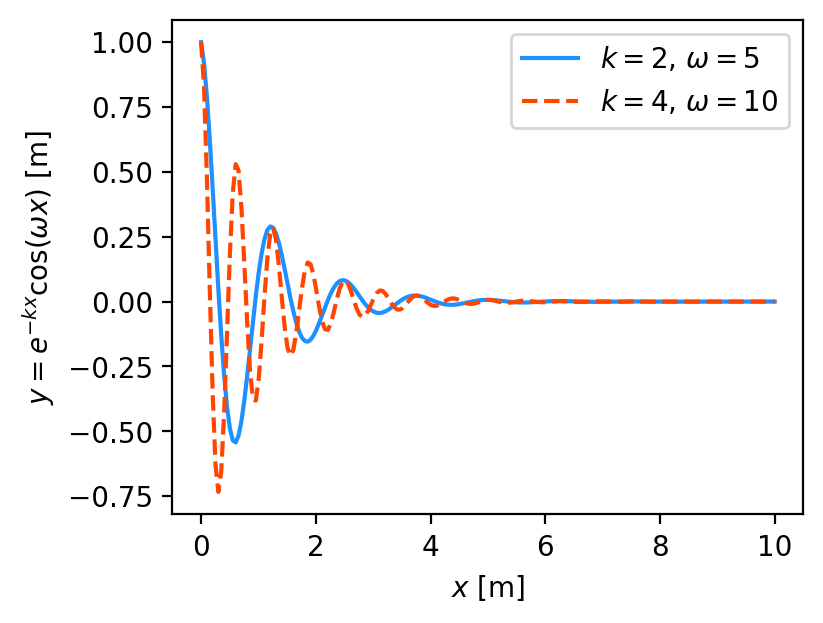

In [22]:
fig, ax = plt.subplots(figsize=(4,3), dpi=200, layout='constrained')

ax.plot(x, osc1, color='dodgerblue', label=rf'$k=${k1}, $\omega=${omega1}')
ax.plot(x, osc2, '--', color='orangered', label=rf'$k=${k2}, $\omega=${omega2}')

ax.set_xlabel(r"$x$ [m]")
ax.set_ylabel(r"$y = e^{-kx}\cos(\omega x)$ [m]")

ax.legend(loc='upper right')

# fig.tight_layout()

plt.show()

Forma 2:

No instanciar una figura ni ejes (forma implícita). Se pueden hacer (casi) las mismas cosas, pero es recomendable para variables que uno quiere graficar rápidamente y ver cómo se comportan. Para gráficos con más sub-gráficos, se recomienda la forma explícita.

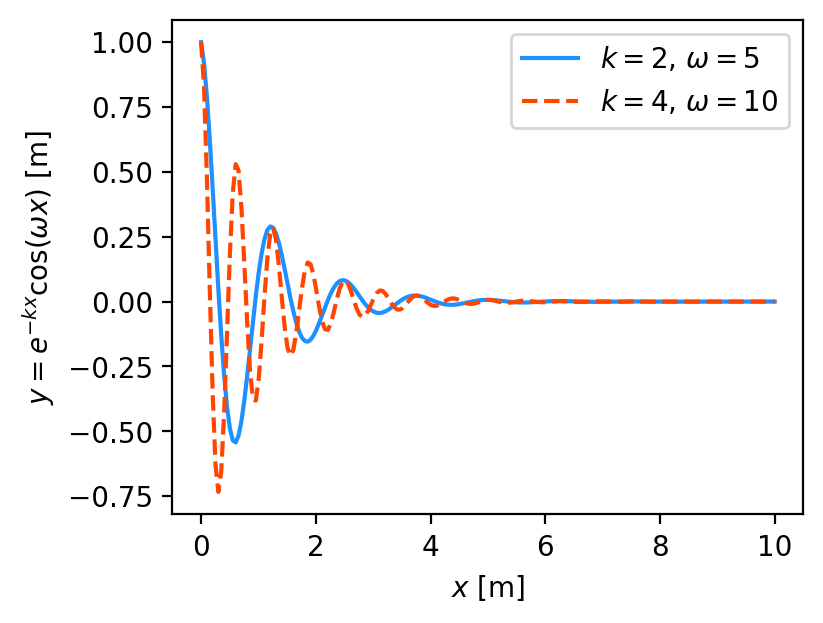

In [23]:
plt.figure(figsize=(4,3), dpi=200, layout='constrained')
plt.plot(x, osc1, color='dodgerblue', label=rf'$k=${k1}, $\omega=${omega1}')
plt.plot(x, osc2, '--', color='orangered', label=rf'$k=${k2}, $\omega=${omega2}')

plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y = e^{-kx}\cos(\omega x)$ [m]")

plt.legend(loc='upper right')

plt.show()